# Tigrinya Text RAW Data Discovery & Statistics

This notebook provides statistics and visualizations for the processed Tigrinya text data used for tokenizer training and model pretraining.

## Contents
1. Data Loading
2. Basic Statistics (lines, words, characters)
3. Vocabulary Analysis & frequency
4. Sample Data Preview

In [1]:
# Imports
import os
import sys

sys.path.append(os.path.dirname(os.path.abspath(os.getcwd())))


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
from data.dataset_stats import (
    get_text_stats, print_stats, get_word_frequency,
    find_duplicates, generate_wordcloud, get_tigrinya_font,
)

def import_text_data(filepath):
    return Path(filepath).read_text(encoding='utf-8')

# Configure matplotlib to use Ethiopic font
ethiopic_font_path = get_tigrinya_font()
if ethiopic_font_path:
    ethiopic_font = fm.FontProperties(fname=ethiopic_font_path)
    print(f"Using Ethiopic font: {ethiopic_font_path}")
else:
    ethiopic_font = None
    print("Warning: No Ethiopic font found. Install Noto Sans Ethiopic for proper rendering.")

Using Ethiopic font: /System/Library/Fonts/Supplemental/Kefa.ttc


In [3]:
# File paths
TRAIN_PATH = '../datasets/raw/train.txt'
VALIDATION_PATH = '../datasets/raw/validation.txt'
ENGLISH_TIGRINYA_BIBLE_PATH = '../datasets/raw/en-ti-bible/train.target'
TIGRINYA_SENTENCES_PATH = '../datasets/raw/tigrinya_sentences.txt'
TIGRINYA_QA_PATH = '../datasets/raw/tigqa/train.parquet'

In [4]:
# Load all datasets

train_data = import_text_data(TRAIN_PATH)
validation_data = import_text_data(VALIDATION_PATH)
english_tigrinya_bible_data = import_text_data(ENGLISH_TIGRINYA_BIBLE_PATH)
tigrinya_sentences_data = import_text_data(TIGRINYA_SENTENCES_PATH)
tigrinya_qa_data = pd.read_parquet(TIGRINYA_QA_PATH)


In [5]:
## Raw Data Statistics


In [6]:
# Compute and display stats for each dataset
datasets = {
    'Train': (train_data, TRAIN_PATH),
    'Validation': (validation_data, VALIDATION_PATH),
    'Bible (Tigrinya)': (english_tigrinya_bible_data, ENGLISH_TIGRINYA_BIBLE_PATH),
    'Tigrinya Sentences': (tigrinya_sentences_data, TIGRINYA_SENTENCES_PATH),
}

all_stats = {}
for name, (data, path) in datasets.items():
    stats = get_text_stats(data, path)
    all_stats[name] = stats
    print_stats(stats, title=name)



 Train
  File Size..................... 414.78 MB
  Total Lines................... 1978213
  Unique Lines.................. 1797551
  Duplicate Count............... 180662
  Duplicate Rate................ 9.13%
  Total Words................... 37518070
  Total Chars................... 135883083
  Vocab Size.................... 1599231
  Avg Line Length............... 19.0 words

 Validation
  File Size..................... 8.40 MB
  Total Lines................... 43335
  Unique Lines.................. 40603
  Duplicate Count............... 2732
  Duplicate Rate................ 6.30%
  Total Words................... 762036
  Total Chars................... 2754297
  Vocab Size.................... 139488
  Avg Line Length............... 17.6 words

 Bible (Tigrinya)
  File Size..................... 34.86 MB
  Total Lines................... 262047
  Unique Lines.................. 254740
  Duplicate Count............... 7307
  Duplicate Rate................ 2.79%
  Total Words.............

In [7]:
# Summary table
summary_df = pd.DataFrame(all_stats).T
summary_df


,file_size,total_lines,unique_lines,duplicate_count,duplicate_rate,total_words,total_chars,vocab_size,avg_line_length
Train,414.78 MB,1978213,1797551,180662,9.13%,37518070,135883083,1599231,19.0 words
Validation,8.40 MB,43335,40603,2732,6.30%,762036,2754297,139488,17.6 words
Bible (Tigrinya),34.86 MB,262047,254740,7307,2.79%,2918059,11222807,366648,11.1 words
Tigrinya Sentences,147.91 MB,715540,696938,18602,2.60%,13944410,48043969,770466,19.5 words


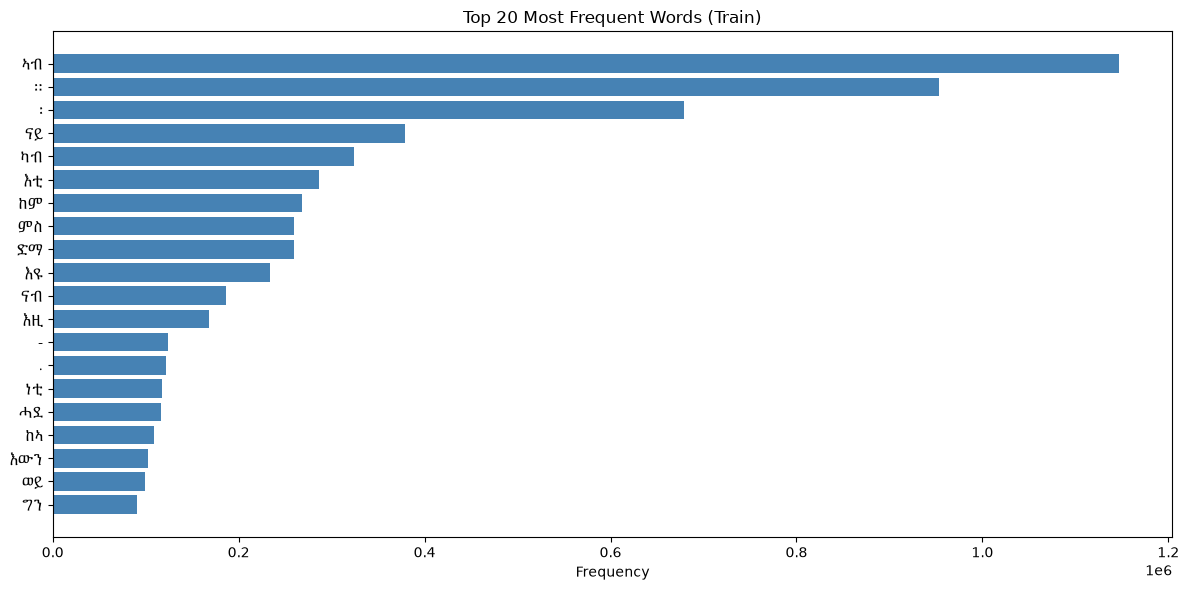

In [8]:
# Top 20 words for train dataset
top_words = get_word_frequency(train_data, top_n=20)

fig, ax = plt.subplots(figsize=(12, 6))
words, counts = zip(*top_words.most_common(20))
ax.barh(range(len(words)), counts, color='steelblue')
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontproperties=ethiopic_font)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 20 Most Frequent Words (Train)')
plt.tight_layout()
plt.show()


## Word Clouds


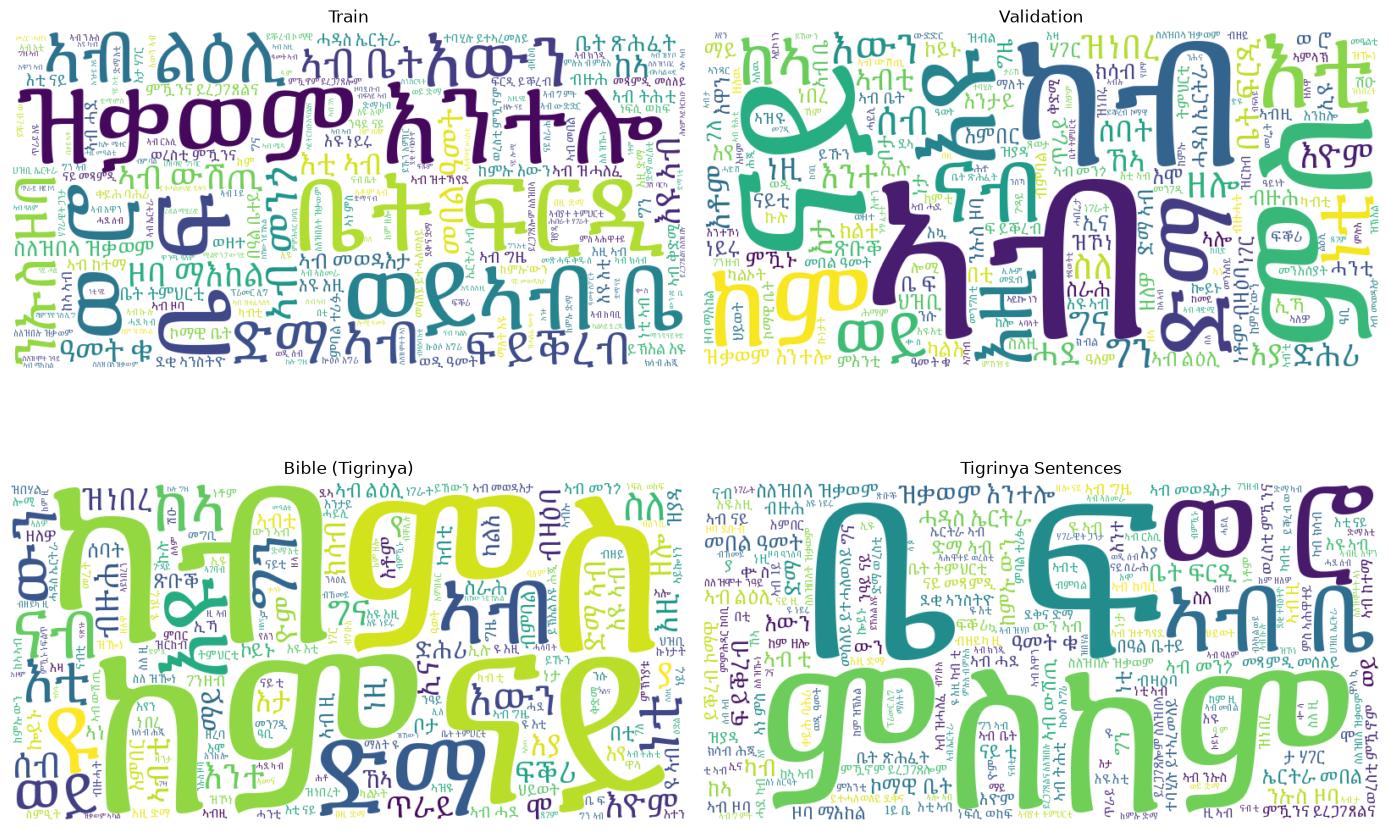

In [10]:
# Generate wordclouds for each dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, (data, _)) in enumerate(datasets.items()):
    try:
        wc = generate_wordcloud(data)
        axes[idx].imshow(wc, interpolation='bilinear')
        axes[idx].set_title(name)
        axes[idx].axis('off')
    except ImportError:
        axes[idx].text(0.5, 0.5, 'Install wordcloud:\npip install wordcloud', 
                       ha='center', va='center', fontsize=12)
        axes[idx].set_title(name)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()


## Duplicate Analysis


In [11]:
# Duplicate analysis for train data
dup_info = find_duplicates(train_data)

print(f"Total lines: {dup_info['total_lines']:,}")
print(f"Unique lines: {dup_info['unique_lines']:,}")
print(f"Duplicates: {dup_info['duplicate_count']:,} ({dup_info['duplicate_rate']:.2f}%)")
print(f"\nTop 10 most repeated lines:")
for line, count in dup_info['top_duplicates']:
    preview = line[:60] + '...' if len(line) > 60 else line
    print(f"  [{count}x] {preview}")


Total lines: 1,978,213
Unique lines: 1,797,551
Duplicates: 180,662 (9.13%)

Top 10 most repeated lines:
  [186x] ከም
  [171x] ብምትሕብባር ሚኒስትሪ ሃብቲ ባሕሪ ዝዳሎ ዓምዲ
  [171x] በዓል ወጻኢ
  [164x] ይብል እግዚኣብሄር ኣምላኽ ።
  [153x] ኣግእዞ
  [153x] ኮማዊ ቤት ፍርዲ ምምሕዳር ከባቢ
  [152x] ሳምራዊት ሃብተ
  [130x] ሚኒስትሪ ዜና
  [127x] ጆርናል
  [120x] ስታድዩም ኣስመራ
